In [1]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx
import json

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"

In [2]:
def visualize_graph(graph: nx.Graph, ax: plt.Axes=None, image_id: str = None, is_spring_layout: bool = False):
    if ax is None:
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111)
    
    if graph is None:
        graph = nx.Graph()
    
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x = node_data['x']['center'] if isinstance(node_data['x'], dict) and 'center' in node_data['x'] else node_data['x']
            y = node_data['y']['center'] if isinstance(node_data['y'], dict) and 'center' in node_data['y'] else node_data['y']
                
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = node_data['x1']
                x2 = node_data['x2']
                y1 = node_data['y1']
                y2 = node_data['y2']
                
                x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
                x2 = x2['center'] if isinstance(x2, dict) and 'center' in x2 else x2
                y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
                y2 = y2['center'] if isinstance(y2, dict) and 'center' in y2 else y2
                
                # Calculate midpoint for vectors
                pos[node_id] = ((x1 + x2) / 2, (y1 + y2) / 2)
    
    node_to_color = {
        "IntersectionPoint": "red",
        "CornerPoint": "green",
        "EndPoint": "blue",
        "QuadrantChangePoint": "purple",
        "StartPoint": "orange"
    }
    # Draw nodes with colors based on their labels
    node_colors = []
    labels_for_nodes = {}
    for node_id in graph.nodes():
        node_data = graph.nodes[node_id]
        
        # Try to get labels from the node data
        labels = []
        if 'labels' in node_data:
            labels = node_data['labels']
            
        labels_for_nodes[node_id] = ', '.join(str(label) for label in labels) + ' ' + str(node_id.split(':')[-1])
        
        # Check if any label matches our color mapping
        color = 'lightblue'  # Default color
        for label in labels:
            label_str = str(label)  # Convert to string if it's not already
            if label_str in node_to_color:
                color = node_to_color[label_str]
                break
        
        node_colors.append(color)
        
    pos = nx.spring_layout(graph) if is_spring_layout else pos
    # Draw the graph
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=2, alpha=0.7, edge_color='gray')
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=8, font_weight='bold', labels=labels_for_nodes)
    
    title = 'Concept Graph' if image_id is None else f'Image {image_id}'
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.invert_yaxis() # Match image coordinates
    ax.margins(x=0.2)  # Add inner padding (10% of data extent)
    # plt.tight_layout()
    
    # return plt.gcf()  # Return the figure for further customization if needed

def visualize_concept_formation_steps(concept_result):
    """
    Visualizes concept formation step-by-step using subplots.

    Each step is shown in a single figure with three subplots:
    1. Left: Concept graph before processing the image.
    2. Center: Current image graph.
    3. Right: Concept graph after processing the image.
    """
    if not concept_result.steps_debug:
        print("No debug steps found in ConceptResult.")
        return

    num_steps = len(concept_result.steps_debug)
    for i, step in enumerate(concept_result.steps_debug):
        print(f"--- Step {step.current_step}/{num_steps} ---")
        print(f"Description: {step.current_step_description}")
        print(f"Processing Image ID: {step.current_image_id}")

        # Create a figure with 3 subplots (1 row, 3 columns)
        fig, axes = plt.subplots(1, 3, figsize=(26, 10)) # Adjust figsize as needed

        # --- Subplot 1: Concept Before ---
        visualize_graph(step.current_concept, ax=axes[0])
        axes[0].set_title(f"Concept BEFORE (Step {step.current_step})")

        # --- Subplot 2: Current Image ---
        visualize_graph(step.current_image, ax=axes[1], image_id=step.current_image_id)
        # Title is set inside visualize_graph for images

        # --- Subplot 3: Concept After ---
        visualize_graph(step.resulted_concept, ax=axes[2])
        axes[2].set_title(f"Concept AFTER (Step {step.current_step})")

        # Add an overall title for the step
        fig.suptitle(f"Concept Formation Step {step.current_step}: {step.current_step_description} (Image {step.current_image_id})", fontsize=16)

        # Adjust layout and display
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap
        plt.show()

        print("-" * 40) # Separator


In [22]:
session_id = "2_1"
concept_name = session_id
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_result = service.create_concept_incrementally(
    session_id, 
    concept_name, 
    # steps=4,
    debug_mode=True
)
concept_graph = concept_result.concept_graph
if concept_result.is_error:
    raise ValueError(concept_result.error_message)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 2_1 using Critical Point approach.
INFO:root:Getting image IDs for session 2_1


ValueError: No images found for session 2_1

--- Step 1/3 ---
Description: Initial concept
Processing Image ID: a4243b40-fe79-49fd-8c58-311f5408e6f6


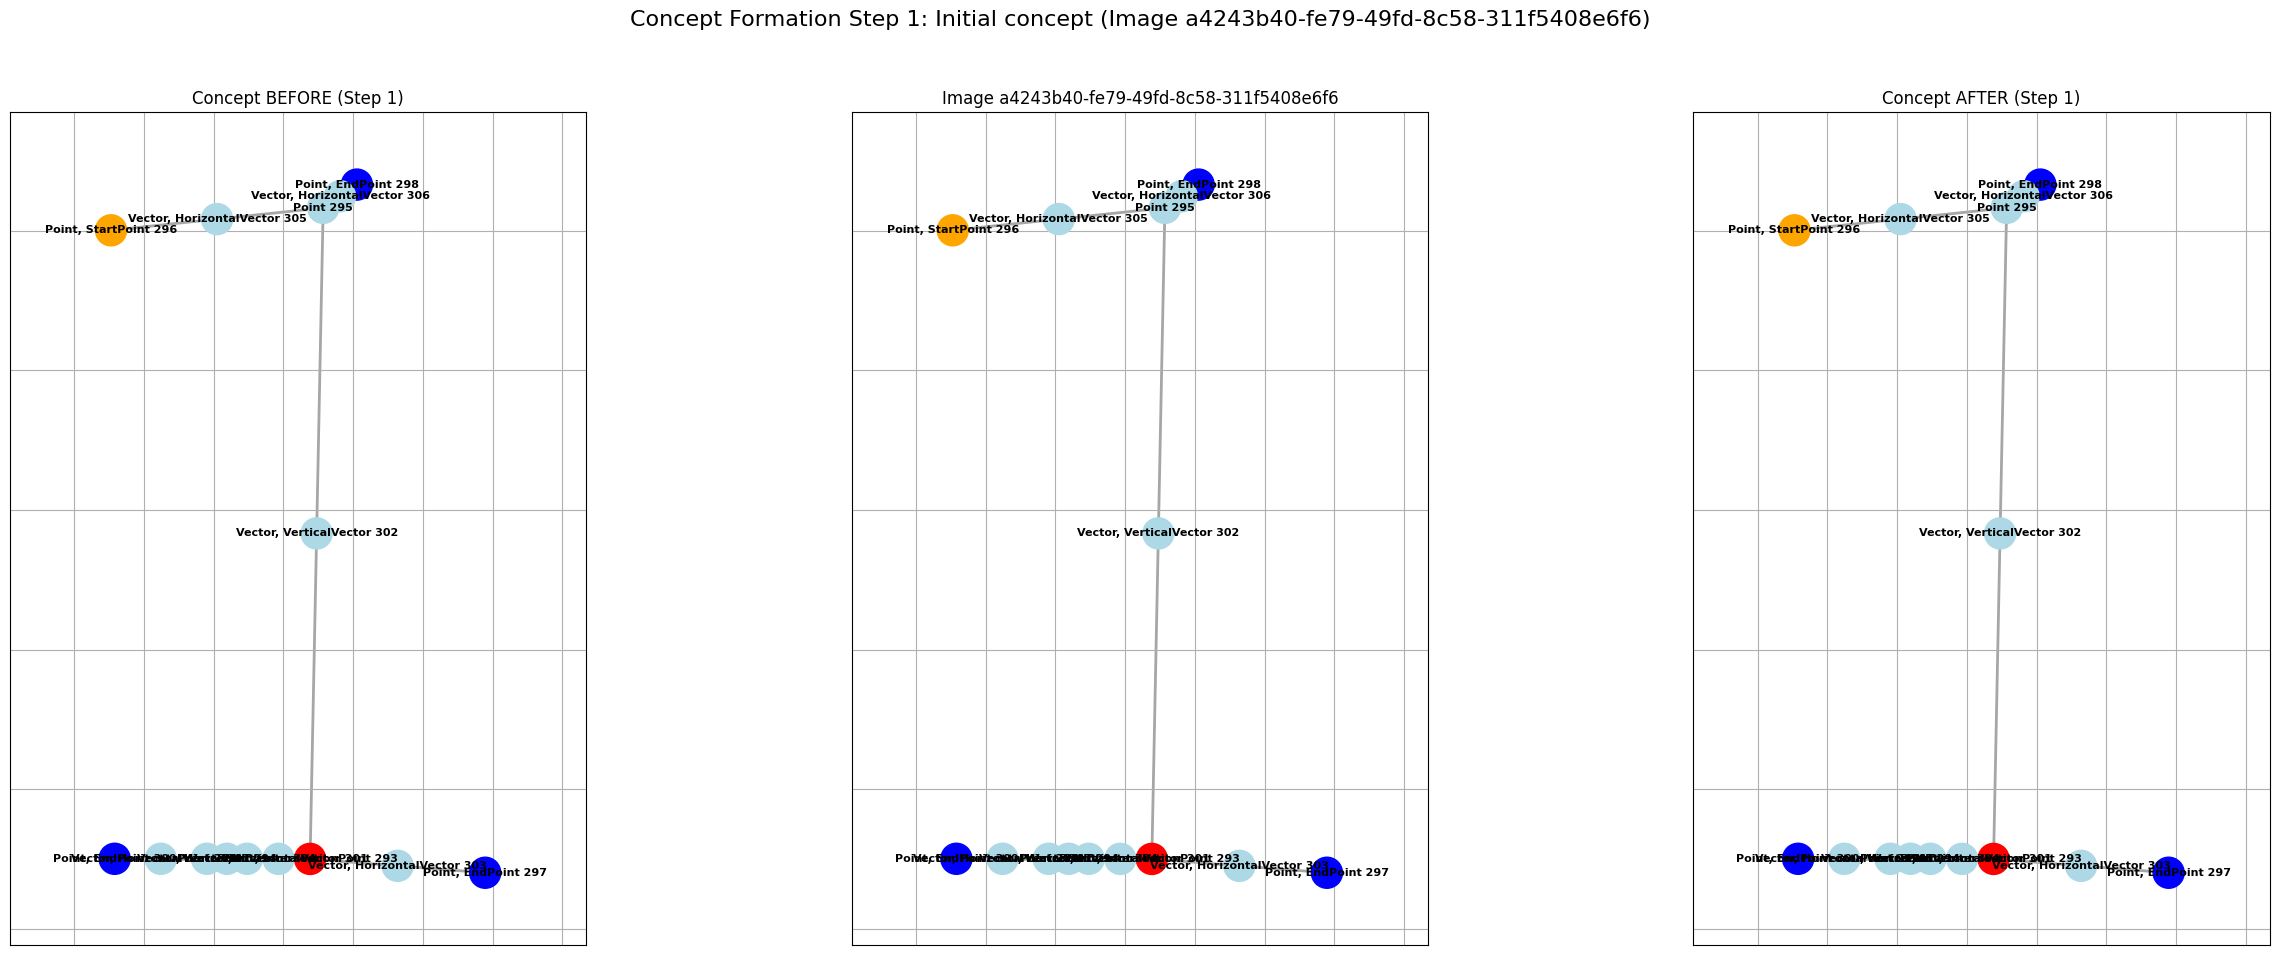

----------------------------------------
--- Step 2/3 ---
Description: Processing image 2/26: e073605e-cc9f-4a71-b87e-676279b0ee04
Processing Image ID: e073605e-cc9f-4a71-b87e-676279b0ee04


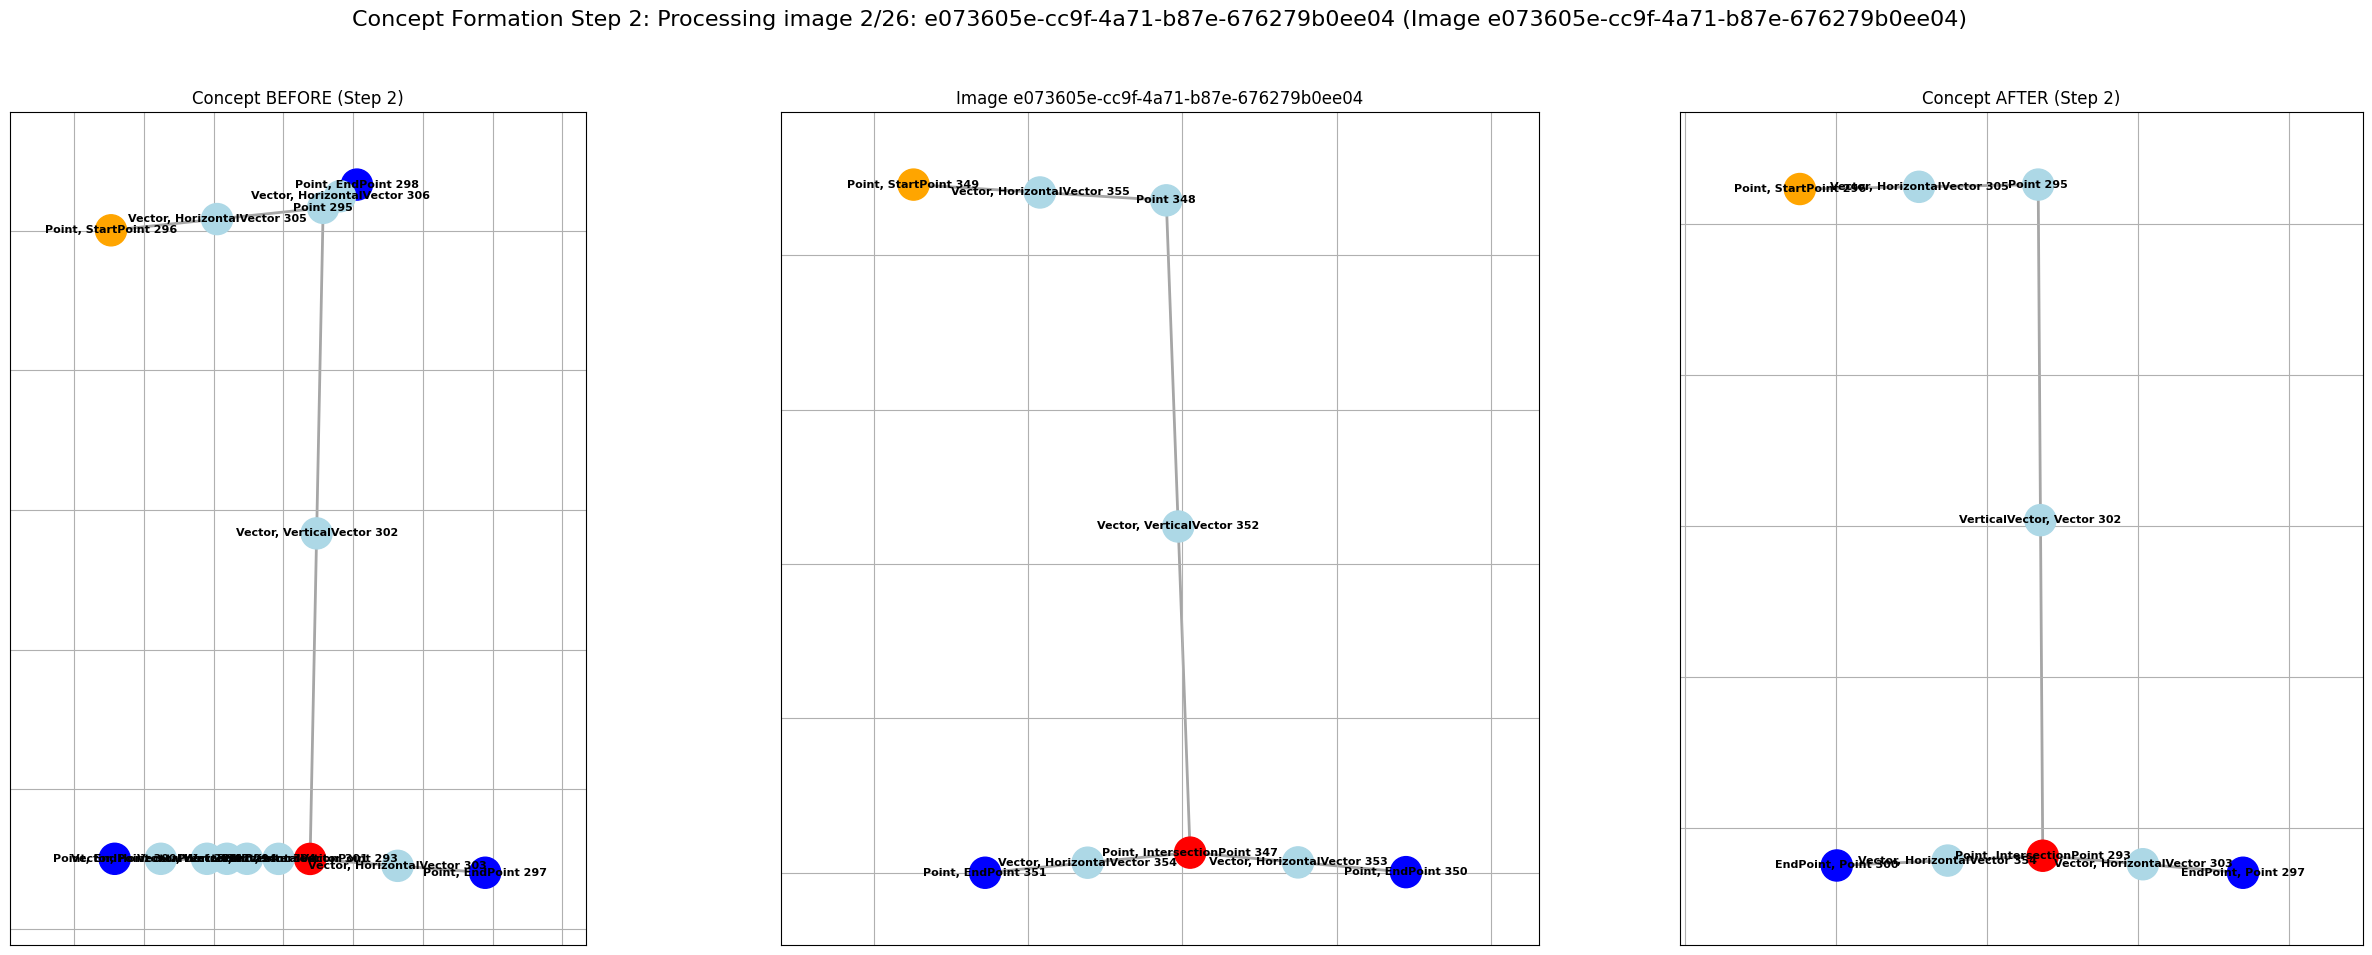

----------------------------------------
--- Step 3/3 ---
Description: Processing image 3/26: ceedf749-831e-4257-af09-7705a8f5b8cc
Processing Image ID: ceedf749-831e-4257-af09-7705a8f5b8cc


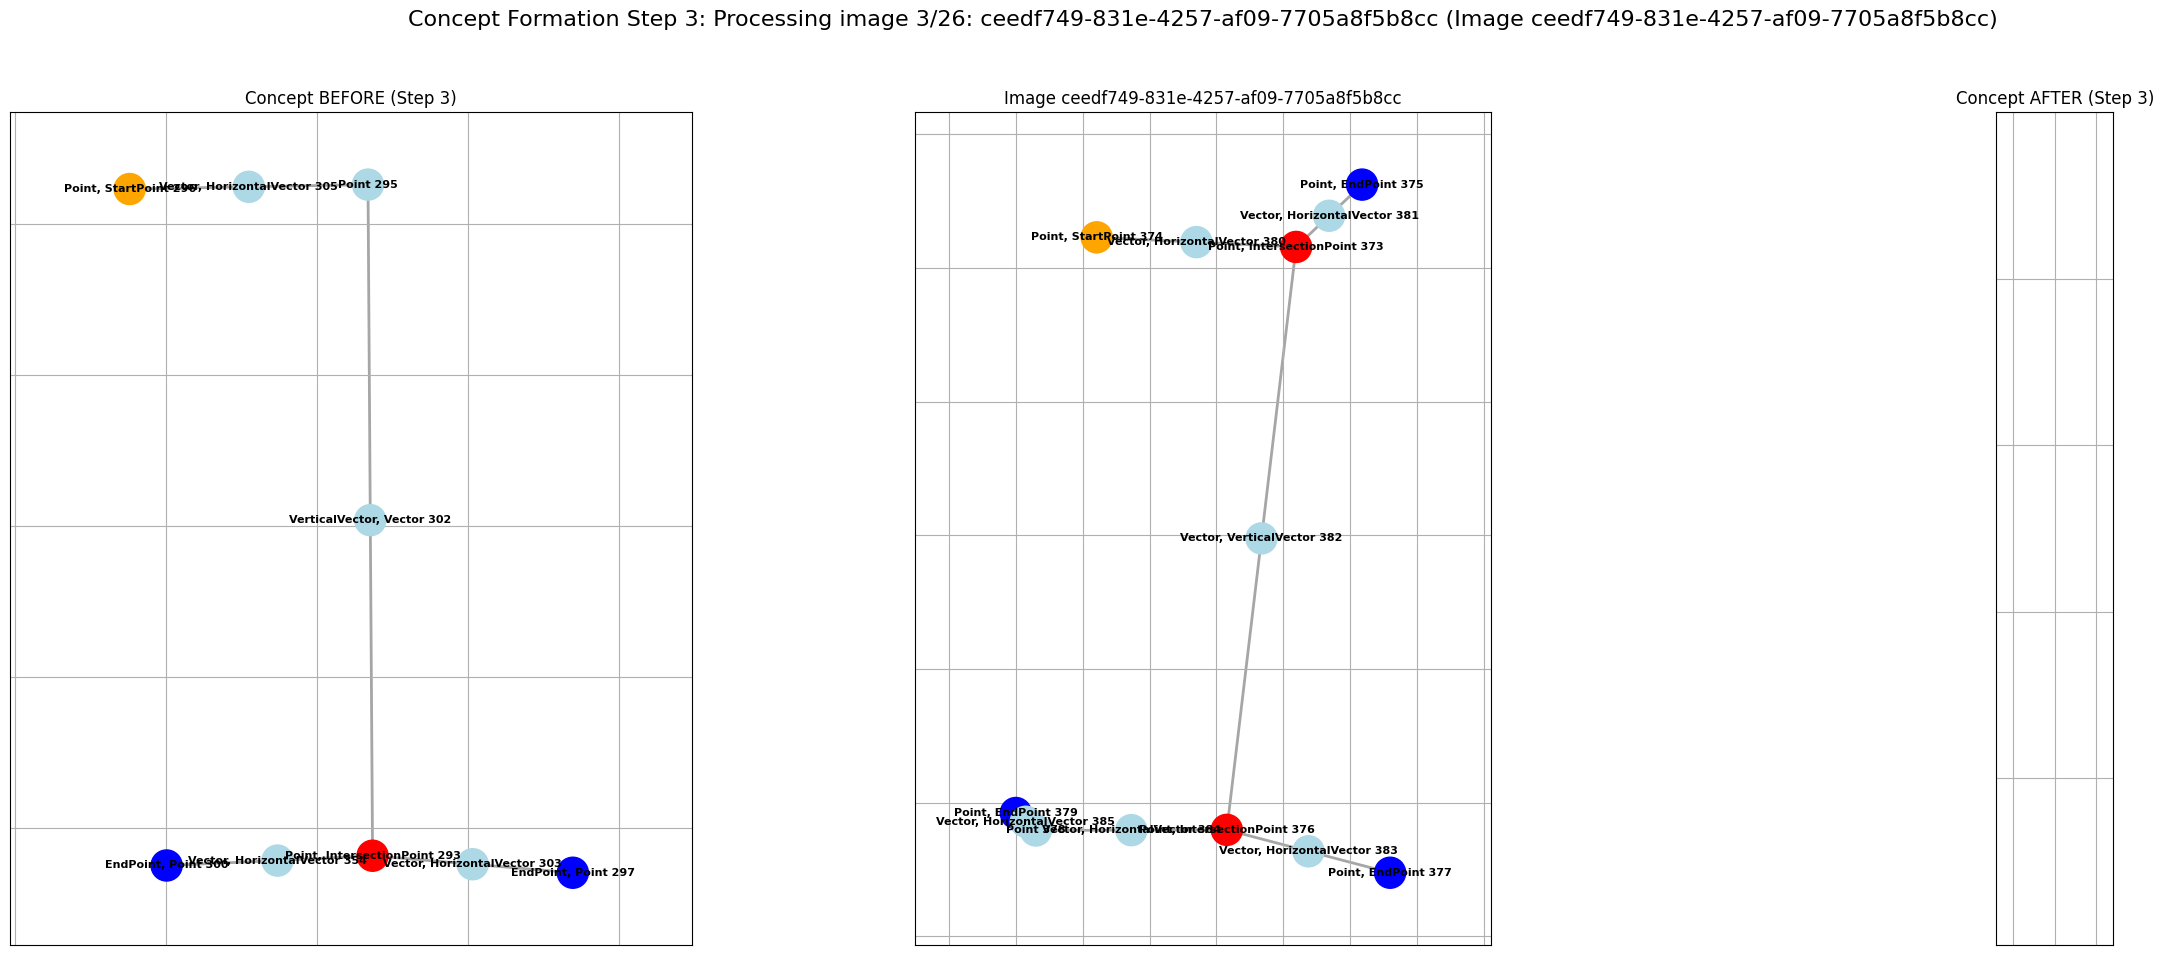

----------------------------------------


In [18]:
# visualize_graph(concept_graph)
visualize_concept_formation_steps(concept_result)

In [ ]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

# Create a directory for saved graphs if it doesn't exist
save_dir = "saved_graphs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(concept_graph)

# Save the graph with a descriptive filename
json_filename = os.path.join(save_dir, "concept_graph.json")
with open(json_filename, "w") as f:
    json.dump(graph_data, f, indent=2)

print(f"Graph saved to {json_filename} in JSON format")



In [ ]:
def _load_graph(json_filename: str) -> nx.Graph:
    with open(json_filename, "r") as f:
        graph_data = json.load(f)
    return nx.node_link_graph(graph_data)

dir_path = "saved_graphs"
iteration = 0
graph1 = _load_graph(f"{dir_path}/{iteration}/graph1.json")
graph2 = _load_graph(f"{dir_path}/{iteration}/graph2.json")
crit_graph1 = _load_graph(f"{dir_path}/{iteration}/crit_graph1.json")
crit_graph2 = _load_graph(f"{dir_path}/{iteration}/crit_graph2.json")

visualize_graph(graph1)
visualize_graph(graph2)
visualize_graph(crit_graph1)
visualize_graph(crit_graph2)


In [ ]:
classes_to_subclasses = {
    # 0: [1],
    1: [1, 2, 3],
    2: [1, 2, 3, 4],
    3: [1, 2, 3],
    4: [1, 2, 3],
    5: [1, 2, 3],
    6: [2, 3],
    7: [1, 2, 3],
    8: [1, 2, 3],
    9: [1, 2, 3],
}

def generate_session_id(class_id: int, subclass_id: int) -> str:
    return f"{class_id}_{subclass_id}"

failed_concepts = []

for class_id in classes_to_subclasses.keys():
    for subclass_id in classes_to_subclasses[class_id]:
        session_id = generate_session_id(class_id, subclass_id)
        service = CriticalPointConceptService(uri, user, password)
        concept_result = service.create_concept_incrementally(
            session_id, 
            concept_id=session_id, 
            # steps=4,
            debug_mode=True
        )
        if concept_result.is_error:
            failed_concepts.append(session_id)
            print(f"Failed to create concept for {session_id}: {concept_result.error_message}")

print(f"Failed concepts: {failed_concepts}")
# Failed concepts: ['2_1', '2_2', '3_2', '4_1', '4_2', '5_1', '5_3', '6_2', '6_3', '7_2', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '2_3', '3_2', '4_1', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '4_1', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_2', '7_3', '8_1', '8_2', '8_3', '9_1', '9_2']
# Failed concepts: ['2_2', '3_2', '4_1', '5_1', '5_3', '6_3', '7_2', '8_1', '8_2', '8_3', '9_1', '9_2']
